# EU G4 Inflation-at-Risk (IaR)

**Macro-financial risk framework for EU G4 (France, Germany, Italy, Spain)**  
Applies the Machado–Santos Silva (2019) location-scale quantile regression approach  
to quantify the conditional distribution of future HICP inflation.

---

### Methodology brief

| Step | Description |
|------|-------------|
| 1 | Pull 8 conditioning series for 29 EU/EEA countries (1999–2025) |
| 2 | MSS location-scale quantile regression, horizons h ∈ {1, 2, 4} |
| 3 | Fit Fernández-Steel skewed-t to P5/P25/P50/P75/P95 quantile predictions |
| 4 | Log-score density pooling across horizons (Crump *et al.* 2022) |
| 5 | Extract IaR P95; re-centre to ECB/AMECO 2027 country baselines |
| 6 | Panel logit de-anchoring early-warning signal (HICP > 3% × 2 yr) |

*References: López-Salido & Loria (2024) JME · Korobilis et al. (2021) ECB WP 2591 · Banerjee et al. (2024) JIMF*

In [1]:
import sys, os, warnings, importlib
warnings.filterwarnings('ignore')

# Make sure the project root is on the path
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')  # safe for notebooks too
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display, Markdown

pd.options.display.float_format = '{:.4f}'.format
print('Environment ready.')

Environment ready.


---
## Phase 1 — Data Pipeline
Fetch / load all eight conditioning series, then merge into a balanced panel.

In [2]:
from data.modules.hicp import load_hicp
from data.modules.ameco import load_ameco
from data.modules.output_gap import load_output_gap
from data.modules.energy_prices import load_energy_prices
from data.modules.food_prices import load_food_prices
from data.modules.import_prices import load_import_prices
from data.modules.imf_fsi import load_fsi
from data.modules.ecb_spreads import load_spreads
from data.modules.labour_costs import load_labour_costs
from data.modules.wui import load_wui
from data.modules.EER import load_neer, load_reer

print('Loading HICP (Eurostat) …')
hicp_df = load_hicp()

print('Loading AMECO inflation expectations …')
ameco_df = load_ameco()

print('Loading OECD output gap …')
ogap_df = load_output_gap()

print('Loading Brent energy prices (FRED) …')
energy_df = load_energy_prices()

print('Loading food prices …')
food_df = load_food_prices()

print('Loading import prices …')
import_df = load_import_prices()

print('Loading ECB CLIFS financial stress …')
fsi_df = load_fsi()

print('Loading Eurostat 10Y bond spreads …')
spreads_df = load_spreads()

print('Loading labour costs by NACE …')
labour_df = load_labour_costs()

print('Loading World Uncertainty Index …')
wui_df = load_wui()

print('Loading NEER workbook …')
neer_wb = load_neer()

print('Loading REER workbook …')
reer_wb = load_reer()

print('\nAll series loaded.')

np.random.seed(42)


Loading HICP (Eurostat) …
Loading AMECO inflation expectations …
Loading OECD output gap …
Loading Brent energy prices (FRED) …
Loading food prices …
Loading import prices …
Loading ECB CLIFS financial stress …
Loading Eurostat 10Y bond spreads …
Loading labour costs by NACE …
Loading World Uncertainty Index …
Loading NEER workbook …
Loading REER workbook …

All series loaded.


In [3]:
from data.panel_builder import build_panel

panel = build_panel()

print(f'Panel shape: {panel.shape}')
print(f'Countries: {panel["iso3"].nunique()}')
print(f'Year range: {panel["year"].min()} – {panel["year"].max()}')
panel.tail(30)

Building IaR monthly estimation panel ...



Panel: 9744 rows x 20 cols
Countries: 29
Period range: 1999-01 to 2026-12
Saved -> /workspaces/inflation_at_risk/data/files/panel.parquet
Panel shape: (9744, 20)
Countries: 29
Year range: 1999 – 2026


,iso3,year,month,hicp,output_gap,infl_expectations,energy_price_chg,import_price_chg,clifs,spread_10y,wui,food_price_chg,labour_cost_chg,neer_chg,reer_chg,hicp_lag,hicp_fwd1,hicp_fwd2,hicp_fwd4,date
9714,SWE,2024,7,1.7000,-1.0000,2.0833,6.3000,9.4278,0.1364,-0.3400,0.0722,0.6517,NaN,1.3593,-0.0291,1.4000,2.0833,2.0917,NaN,2024-07-31
9715,SWE,2024,8,1.3000,-1.0000,2.0833,-6.7200,9.4278,0.0541,-0.2800,0.0722,0.8958,NaN,3.9371,2.3600,1.7000,2.2583,2.1000,NaN,2024-08-31
9716,SWE,2024,9,1.2000,-1.0000,2.0833,-21.0300,9.4278,0.0626,-0.2400,0.0722,1.7008,NaN,5.5283,4.0374,1.3000,2.4250,2.1125,NaN,2024-09-30
9717,SWE,2024,10,1.6000,-1.0000,1.3089,-16.5200,1.6636,0.0609,-0.1900,0.0753,1.5667,NaN,3.1241,1.9188,1.2000,2.5500,2.1083,NaN,2024-10-31
9718,SWE,2024,11,2.0000,-1.0000,1.3089,-10.3600,1.6636,0.0480,-0.2400,0.0753,1.4505,NaN,-0.1990,-1.1008,1.6000,2.5667,2.0875,NaN,2024-11-30
9719,SWE,2024,12,1.6000,-1.0000,1.3089,-4.8600,1.6636,0.0446,-0.0800,0.0753,1.1470,NaN,-2.4822,-3.8340,2.0000,2.6083,2.0833,NaN,2024-12-31
9720,SWE,2025,1,2.0000,-0.5000,0.8859,-1.0700,3.7627,0.0259,-0.1640,0.1765,1.5740,NaN,-1.7739,-2.8366,1.6000,2.6083,NaN,NaN,2025-01-31
9721,SWE,2025,2,2.8000,-0.5000,0.8859,-9.6300,3.7627,0.0705,-0.1450,0.1765,3.1946,NaN,-0.3081,-0.5381,2.0000,2.5167,NaN,NaN,2025-02-28
9722,SWE,2025,3,2.1000,-0.5000,0.8859,-14.8400,3.7627,0.1267,-0.1410,0.1765,4.6696,NaN,3.3336,2.5157,2.8000,2.4667,NaN,NaN,2025-03-31
9723,SWE,2025,4,2.1000,-0.5000,0.4001,-24.2400,13.1854,0.1460,-0.0900,0.3927,4.3481,NaN,7.6068,6.7099,2.1000,2.4167,NaN,NaN,2025-04-30


In [4]:
# ── QA: Data coverage heatmap ───────────────────────────────────────────────
COND_VARS = [
    'hicp_lag', 'output_gap', 'infl_expectations', 'energy_price_chg',
    'import_price_chg', 'clifs', 'spread_10y', 'wui'
]

coverage = (
    panel.groupby('iso3')[COND_VARS]
    .apply(lambda df: df.notna().mean())
    .round(2)
)
display(Markdown('### Coverage rate by country and variable (1 = fully observed)'))
display(coverage.style.background_gradient(cmap='YlGn', axis=None).format('{:.0%}'))

### Coverage rate by country and variable (1 = fully observed)

,hicp_lag,output_gap,infl_expectations,energy_price_chg,import_price_chg,clifs,spread_10y,wui
iso3,,,,,,,,
AUT,100%,96%,100%,100%,100%,100%,100%,96%
BEL,100%,96%,100%,100%,100%,100%,100%,96%
BGR,100%,79%,100%,100%,100%,96%,86%,96%
CYP,100%,79%,100%,100%,100%,100%,93%,0%
CZE,100%,79%,100%,100%,100%,100%,96%,96%
DEU,100%,100%,100%,100%,100%,100%,100%,96%
DNK,100%,96%,100%,100%,100%,100%,100%,96%
ESP,100%,100%,100%,100%,100%,100%,100%,96%
EST,100%,79%,100%,100%,100%,43%,25%,0%


In [5]:
# -- QA: G4 HICP headline values --------------------------------------------
G4 = ['FRA', 'DEU', 'ITA', 'ESP']

# Panel is monthly now; aggregate to annual mean before pivoting.
g4_hicp = (
    panel[panel['iso3'].isin(G4)]
    .groupby(['year', 'iso3'], as_index=False)['hicp']
    .mean()
    .pivot(index='year', columns='iso3', values='hicp')
    .tail(10)
)
print('G4 HICP (% change, annual average from monthly panel, last 10 years):')
display(g4_hicp.round(2))

# Expected: 2022 values should be ~5-8% for all G4
assert g4_hicp.loc[2022].min() > 3.0, 'ERROR: 2022 inflation should be >3% for all G4'
print('\n✓ 2022 G4 HICP values pass sanity check (peak >3% for all countries).')

G4 HICP (% change, annual average from monthly panel, last 10 years):


iso3,DEU,ESP,FRA,ITA
year,,,,
2017,1.7300,2.0300,1.1700,1.3200
2018,1.9000,1.7200,2.1000,1.2400
2019,1.3800,0.7800,1.2900,0.6500
2020,0.3800,-0.3300,0.5300,-0.1800
2021,3.2000,3.0100,2.0700,1.9400
2022,8.6300,8.3300,5.9000,8.7200
2023,6.0700,3.4300,5.6800,6.0300
2024,2.5100,2.8700,2.3200,1.0600
2025,2.2500,2.6900,0.9200,1.6200



✓ 2022 G4 HICP values pass sanity check (peak >3% for all countries).


---
## Phase 2 — MSS Location-Scale Quantile Regression
Three-step estimator. Produces quantile predictions at τ ∈ {0.05, 0.25, 0.50, 0.75, 0.95}  
for each horizon h ∈ {1, 2, 4}.

In [6]:
from model.location_scale import run_all

print('Running MSS location-scale quantile regression …')
print('Horizons: h = 1, 2, 4 years')
print('This may take 1-2 minutes …\n')

results = run_all(panel)

print(f'\nResults keys: {list(results.keys())}')

Running MSS location-scale quantile regression …
Horizons: h = 1, 2, 4 years
This may take 1-2 minutes …


  Horizon h=1:
    hicp_lag … 775 rows
    output_gap … 701 rows
    infl_expectations … 775 rows
    energy_price_chg … 775 rows
    import_price_chg … 775 rows
    clifs …     ⚠ Sign check for clifs h=1: γ=1.520 (expected −)
719 rows
    spread_10y … 695 rows
    wui …     ⚠ Sign check for wui h=1: γ=-0.058 (expected +)
667 rows
    food_price_chg …     ⚠ Sign check for food_price_chg h=1: β=-0.011 (expected +), γ=-0.007 (expected +)
574 rows
    labour_cost_chg … 620 rows
    neer_chg … 775 rows
    reer_chg … 775 rows

  Horizon h=2:
    hicp_lag … 746 rows
    output_gap … 672 rows
    infl_expectations … 746 rows
    energy_price_chg … 746 rows
    import_price_chg … 746 rows
    clifs …     ⚠ Sign check for clifs h=2: γ=0.097 (expected −)
692 rows
    spread_10y … 667 rows
    wui … 642 rows
    food_price_chg …     ⚠ Sign check for food_price_chg h=2: β=-0.036 (expected +)

In [7]:
# ── Coefficient sign check ───────────────────────────────────────────────────
# sign checks are run internally by run_all() and printed above
print("Sign checks logged during run_all(). See output above.")
for h in sorted(results['horizon'].unique()):
    n = len(results[results['horizon'] == h])
    print(f'  h={h}: {n} prediction rows')

Sign checks logged during run_all(). See output above.
  h=1: 8626 prediction rows
  h=2: 8288 prediction rows
  h=4: 7612 prediction rows


In [8]:
# ── Show quantile predictions for G4 ────────────────────────────────────────
h2_preds = results[results['horizon'] == 2]
g4_preds = h2_preds[h2_preds['iso3'].isin(G4)].tail(12)
print('h=2 quantile predictions (G4, last 3 years):')
display(g4_preds.round(3))

h=2 quantile predictions (G4, last 3 years):


,iso3,year,horizon,cond_var,Q05,Q25,Q50,Q75,Q95
16592,ITA,2013,2,reer_chg,-0.1480,1.1430,1.7560,2.4400,5.0170
16593,ITA,2014,2,reer_chg,-0.5040,0.6910,1.2580,1.8920,4.2770
16594,ITA,2015,2,reer_chg,-0.1720,1.0250,1.5930,2.2280,4.6170
16595,ITA,2016,2,reer_chg,-0.7160,0.4460,0.9970,1.6130,3.9320
16596,ITA,2017,2,reer_chg,-0.0980,1.1860,1.7950,2.4760,5.0380
16597,ITA,2018,2,reer_chg,-0.2300,1.0450,1.6490,2.3250,4.8700
16598,ITA,2019,2,reer_chg,-0.1020,1.1390,1.7270,2.3850,4.8630
16599,ITA,2020,2,reer_chg,-0.7070,0.4530,1.0030,1.6190,3.9350
16600,ITA,2021,2,reer_chg,0.1020,1.4130,2.0350,2.7310,5.3480
16601,ITA,2022,2,reer_chg,2.9820,4.8610,5.7530,6.7490,10.4990


---
## Phase 3a — Fernández-Steel Skewed-t Distribution Fitting
Fit a skewed-t to the five conditional quantiles per country-horizon.

In [9]:
from model.quantile_fit import fit_distributions

skt_params = {}
for h in sorted(results['horizon'].unique()):
    preds = results[results['horizon'] == h]
    skt_params[h] = fit_distributions(preds)
    print(f'h={h}: fitted distributions for {len(skt_params[h])} country-year observations')

# Show G4 h=2 parameters
g4_skt = skt_params[2][skt_params[2]['iso3'].isin(G4)].tail(8)
print('\nSKT parameters (G4, h=2):')
display(g4_skt.round(4))

  Fitting skewed-t for 3054 rows (analytical approximation) …


  3054 / 3054 fitted successfully.
  Saved → /workspaces/inflation_at_risk/model/skt_params.parquet
h=1: fitted distributions for 3054 country-year observations
  Fitting skewed-t for 2935 rows (analytical approximation) …
  2935 / 2935 fitted successfully.
  Saved → /workspaces/inflation_at_risk/model/skt_params.parquet
h=2: fitted distributions for 2935 country-year observations
  Fitting skewed-t for 2697 rows (analytical approximation) …
  2697 / 2697 fitted successfully.
  Saved → /workspaces/inflation_at_risk/model/skt_params.parquet
h=4: fitted distributions for 2697 country-year observations

SKT parameters (G4, h=2):


,iso3,year,horizon,cond_var,Q05,Q25,Q50,Q75,Q95,xi,omega,alpha,nu
2875,ITA,2017,2,reer_chg,-0.0978,1.1862,1.7951,2.4758,5.0382,1.7951,0.8214,0.2692,2.5000
2876,ITA,2018,2,reer_chg,-0.2305,1.0447,1.6494,2.3253,4.8701,1.6494,0.8157,0.2692,2.5000
2877,ITA,2019,2,reer_chg,-0.1024,1.1388,1.7275,2.3854,4.8626,1.7275,0.7940,0.2692,2.5000
2878,ITA,2020,2,reer_chg,-0.7074,0.4531,1.0035,1.6186,3.9347,1.0035,0.7424,0.2692,2.5000
2879,ITA,2021,2,reer_chg,0.1020,1.4134,2.0354,2.7305,5.3478,2.0354,0.8389,0.2692,2.5000
2880,ITA,2022,2,reer_chg,2.9823,4.8614,5.7526,6.7487,10.4988,5.7526,1.2020,0.2692,2.5000
2881,ITA,2023,2,reer_chg,2.0498,3.8205,4.6602,5.5988,9.1325,4.6602,1.1327,0.2692,2.5000
2882,ITA,2024,2,reer_chg,-0.0689,1.1952,1.7946,2.4647,4.9873,1.7946,0.8086,0.2692,2.5000


---
## Phase 3b — Log-Score Density Pooling
Combine h=1, h=2, h=4 predictive distributions via log-score weights.

In [10]:
from risk.pooling import compute_country_weights

G4_LABELS = {'FRA': 'France', 'DEU': 'Germany', 'ITA': 'Italy', 'ESP': 'Spain'}

weights = {}
for iso3 in G4:
    params_by_h = {h: skt_params[h][skt_params[h]['iso3'] == iso3] for h in [1, 2, 4]}
    hicp_actual = panel[panel['iso3'] == iso3][['year', 'hicp']]
    w = compute_country_weights(params_by_h, hicp_actual, horizons=[1, 2, 4])
    weights[iso3] = w
    print(f'{G4_LABELS[iso3]}: h=[1,2,4] weights = {w}')

France: h=[1,2,4] weights = [6.57622144e-01 1.00000000e-06 3.42376856e-01]
Germany: h=[1,2,4] weights = [7.29720543e-01 1.00000000e-06 2.70278457e-01]
Italy: h=[1,2,4] weights = [0.68291168 0.03520195 0.28188638]
Spain: h=[1,2,4] weights = [0.3212572  0.06796558 0.61077722]


---
## Phase 3c — IaR Extraction with ECB Baseline Re-centring
Extract P5/P50/P95 from pooled distribution; re-centre median to ECB/AMECO 2027 projection.

In [11]:
from risk.iar import compute_iar

iar = compute_iar(
    skt_params  = skt_params,
    weights     = weights,
    ameco_df    = ameco_df,
    panel       = panel,
    countries   = G4,
    horizon     = 2,
)

print('\nInflation-at-Risk Results:')
display(iar[['iso3', 'ecb_baseline', 'Q05', 'Q50', 'Q95', 'IaR', 'Upside', 'Downside']].round(2))

# Sanity check: P95 > ECB baseline > P05
for _, row in iar.iterrows():
    assert row['Q95'] > row['ecb_baseline'] > row['Q05'], \
        f"{row['iso3']}: quantile ordering violated!"
print('\n✓ IaR quantile ordering satisfied for all G4 countries.')

Saved IaR results → /workspaces/inflation_at_risk/risk/iar_results.parquet
  iso3    Q05    Q50    Q95    IaR  Upside  Downside  ecb_baseline
0  FRA 1.0100 1.5300 4.3500 4.3500  2.8200    0.5200        1.5287
1  DEU 1.4400 2.3000 4.9200 4.9200  2.6200    0.8600        2.2994
2  ITA 1.1100 1.7700 4.7000 4.7000  2.9300    0.6700        1.7717
3  ESP 1.2600 1.8600 4.6900 4.6900  2.8300    0.6000        1.8629

Inflation-at-Risk Results:


,iso3,ecb_baseline,Q05,Q50,Q95,IaR,Upside,Downside
0,FRA,1.5300,1.0100,1.5300,4.3500,4.3500,2.8200,0.5200
1,DEU,2.3000,1.4400,2.3000,4.9200,4.9200,2.6200,0.8600
2,ITA,1.7700,1.1100,1.7700,4.7000,4.7000,2.9300,0.6700
3,ESP,1.8600,1.2600,1.8600,4.6900,4.6900,2.8300,0.6000



✓ IaR quantile ordering satisfied for all G4 countries.


In [12]:
# ── AMECO country-specificity check ─────────────────────────────────────────
baseline_values = iar.set_index('iso3')['ecb_baseline'].to_dict()
print('ECB/AMECO baseline re-centring values (2027 forecast):')
for iso3, v in baseline_values.items():
    print(f'  {iso3}: {v:.2f}%')

# All four must be different
assert len(set(baseline_values.values())) == len(baseline_values), \
    'ERROR: All G4 baselines are identical — expected country-specific values'
print('\n✓ Country-specific AMECO baselines confirmed (all distinct).')

ECB/AMECO baseline re-centring values (2027 forecast):
  FRA: 1.53%
  DEU: 2.30%
  ITA: 1.77%
  ESP: 1.86%

✓ Country-specific AMECO baselines confirmed (all distinct).


---
## Phase 4 — De-anchoring Early-Warning Signal
Panel logit: P(HICP > 3% for 2 consecutive years) ~ Λ(β × Upside_risk)

In [13]:
import importlib
import crisis.deanchoring_signal as _ds_mod
importlib.reload(_ds_mod)
from crisis.deanchoring_signal import run_deanchoring

print('Running de-anchoring panel logit …')
daresults, pooled_scores = run_deanchoring(
    skt_params     = skt_params,
    panel          = panel,
    iar            = iar,
    countries      = G4,
    forecast_years = [2026, 2027],
)

print('\nModel summary:')
print(daresults.summary())


Running de-anchoring panel logit …
  De-anchoring base rate: 0.293 (2813 episodes)
    hicp_lag: β=6.733, p=0.000
    output_gap: β=0.195, p=0.000
    infl_expectations: β=5.835, p=0.000
    energy_price_chg: β=2.660, p=0.000
    import_price_chg: β=2.157, p=0.000
    clifs: β=12.288, p=0.000
    spread_10y: β=13.247, p=0.000
    wui: β=2.196, p=0.000
    food_price_chg: β=4.687, p=0.000
    labour_cost_chg: β=7.394, p=0.000
    neer_chg: β=9.863, p=0.000
    reer_chg: β=8.611, p=0.000
  Saved de-anchoring scores → /workspaces/inflation_at_risk/crisis/deanchoring_scores.parquet
  Saved pooled scores → /workspaces/inflation_at_risk/crisis/deanchoring_pooled.parquet

Model summary:
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                35220
Model:                          Logit   Df Residuals:                    35218
Method:                           MLE   Df Model:                         

In [14]:
print('G4 De-anchoring Probability Scores:')
display(
    pooled_scores
    .pivot(index='iso3', columns='year', values='pooled_prob')
    .rename(columns=lambda c: f'P(deanchor) {c}')
    .round(3)
)

# Check country ranking: ITA/ESP ≥ DEU
probs_2026 = pooled_scores[pooled_scores['year'] == 2026].set_index('iso3')['pooled_prob'].to_dict()
if probs_2026:
    max_country = max(probs_2026, key=probs_2026.get)
    print(f'\nHighest de-anchoring probability in 2026: {G4_LABELS.get(max_country, max_country)}')
    assert max_country in ['ITA', 'ESP', 'FRA'], \
        f'Germany highest? Unexpected ranking: {probs_2026}'


G4 De-anchoring Probability Scores:


year,P(deanchor) 2026,P(deanchor) 2027
iso3,,
DEU,0.0200,0.1620
ESP,0.0240,0.2090
FRA,0.0140,0.1590
ITA,0.0170,0.0420



Highest de-anchoring probability in 2026: Spain


---
## Phase 5 — Charts
Generate all four charts and display inline.

In [15]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from output.charts import generate_all_charts

chart_paths = generate_all_charts(
    panel         = panel,
    iar           = iar,
    pooled_scores = pooled_scores,
    base_rate     = 0.20,
    horizon       = 2,
)

print('\nGenerated charts:')
for name, path in chart_paths.items():
    print(f'  {name}: {path}')


Generating IaR charts …
  Chart 1: Fan charts …


  Saved → /workspaces/inflation_at_risk/output/fig1_fan_charts.png
  Chart 2: Asymmetry bar …
  Saved → /workspaces/inflation_at_risk/output/fig2_asymmetry.png
  Chart 3: Waterfall decomposition …
  Saved → /workspaces/inflation_at_risk/output/fig3_waterfall.png
  Chart 4: De-anchoring signal …
  Saved → /workspaces/inflation_at_risk/output/fig4_deanchoring.png
  All charts saved to /workspaces/inflation_at_risk/output/

Generated charts:
  fan: /workspaces/inflation_at_risk/output/fig1_fan_charts.png
  asymmetry: /workspaces/inflation_at_risk/output/fig2_asymmetry.png
  waterfall: /workspaces/inflation_at_risk/output/fig3_waterfall.png
  deanchoring: /workspaces/inflation_at_risk/output/fig4_deanchoring.png


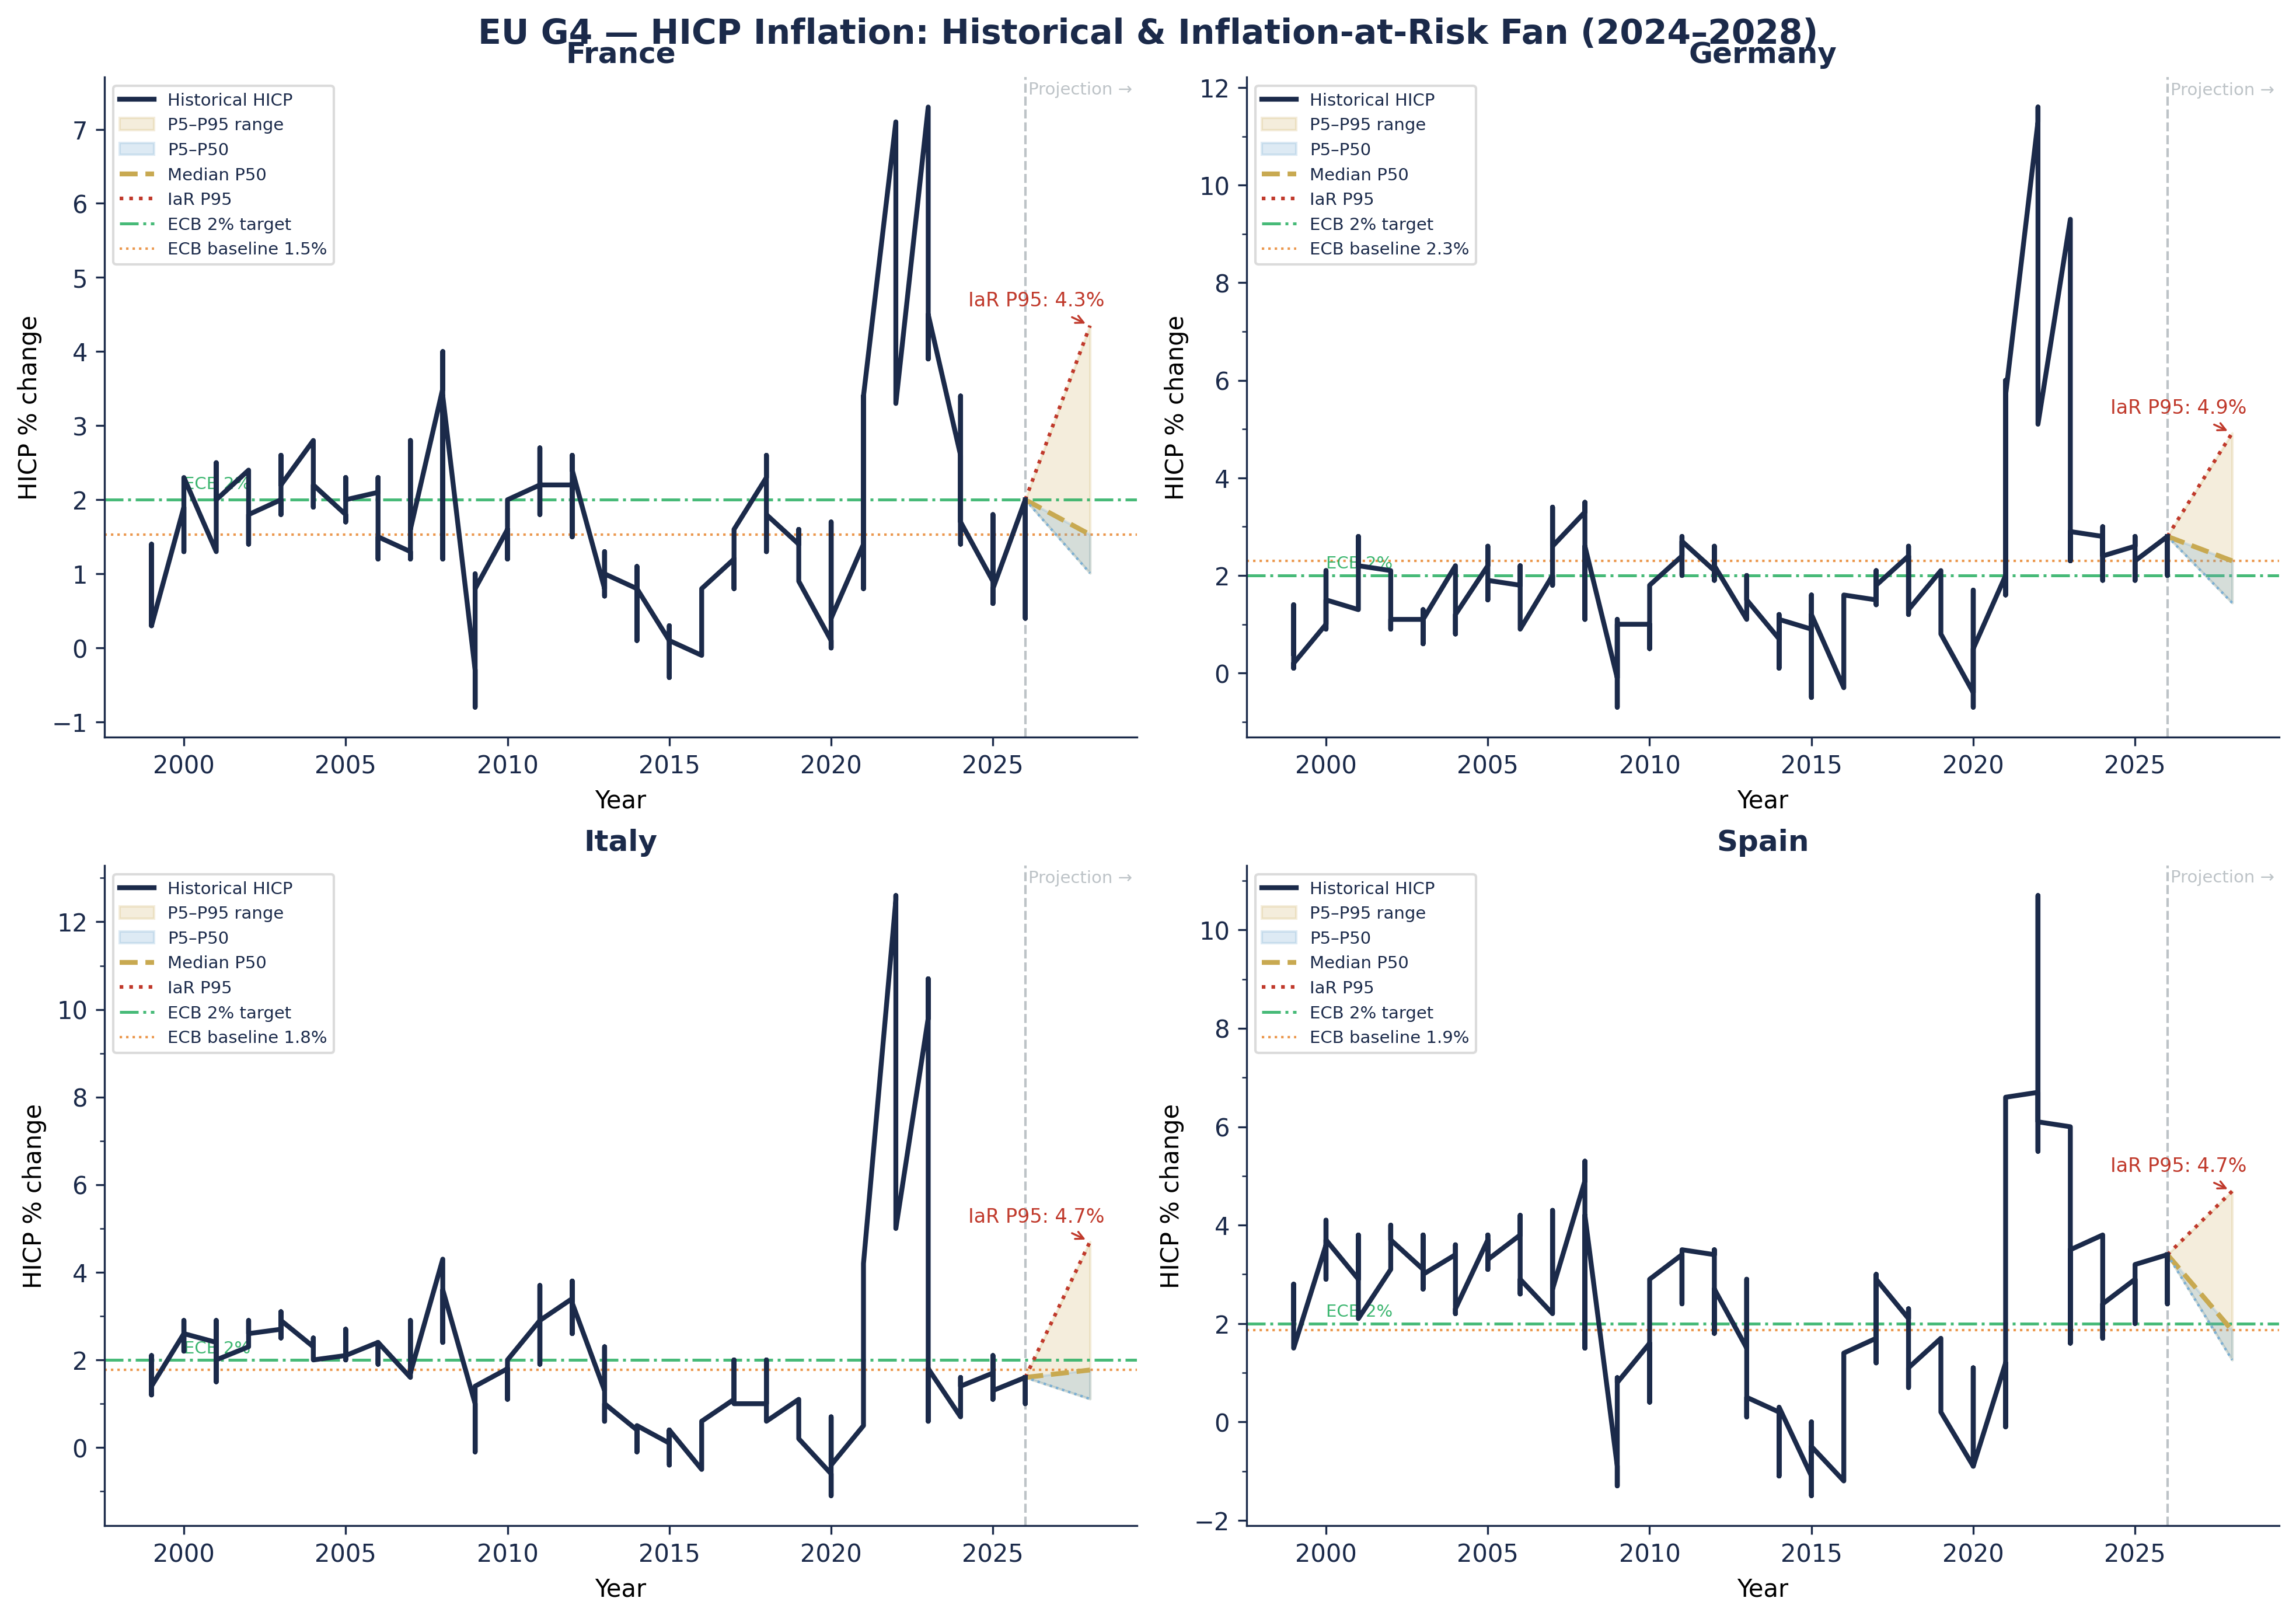

In [16]:
# ── Chart 1: Fan charts ──────────────────────────────────────────────────────
display(Image(str(chart_paths['fan'])))

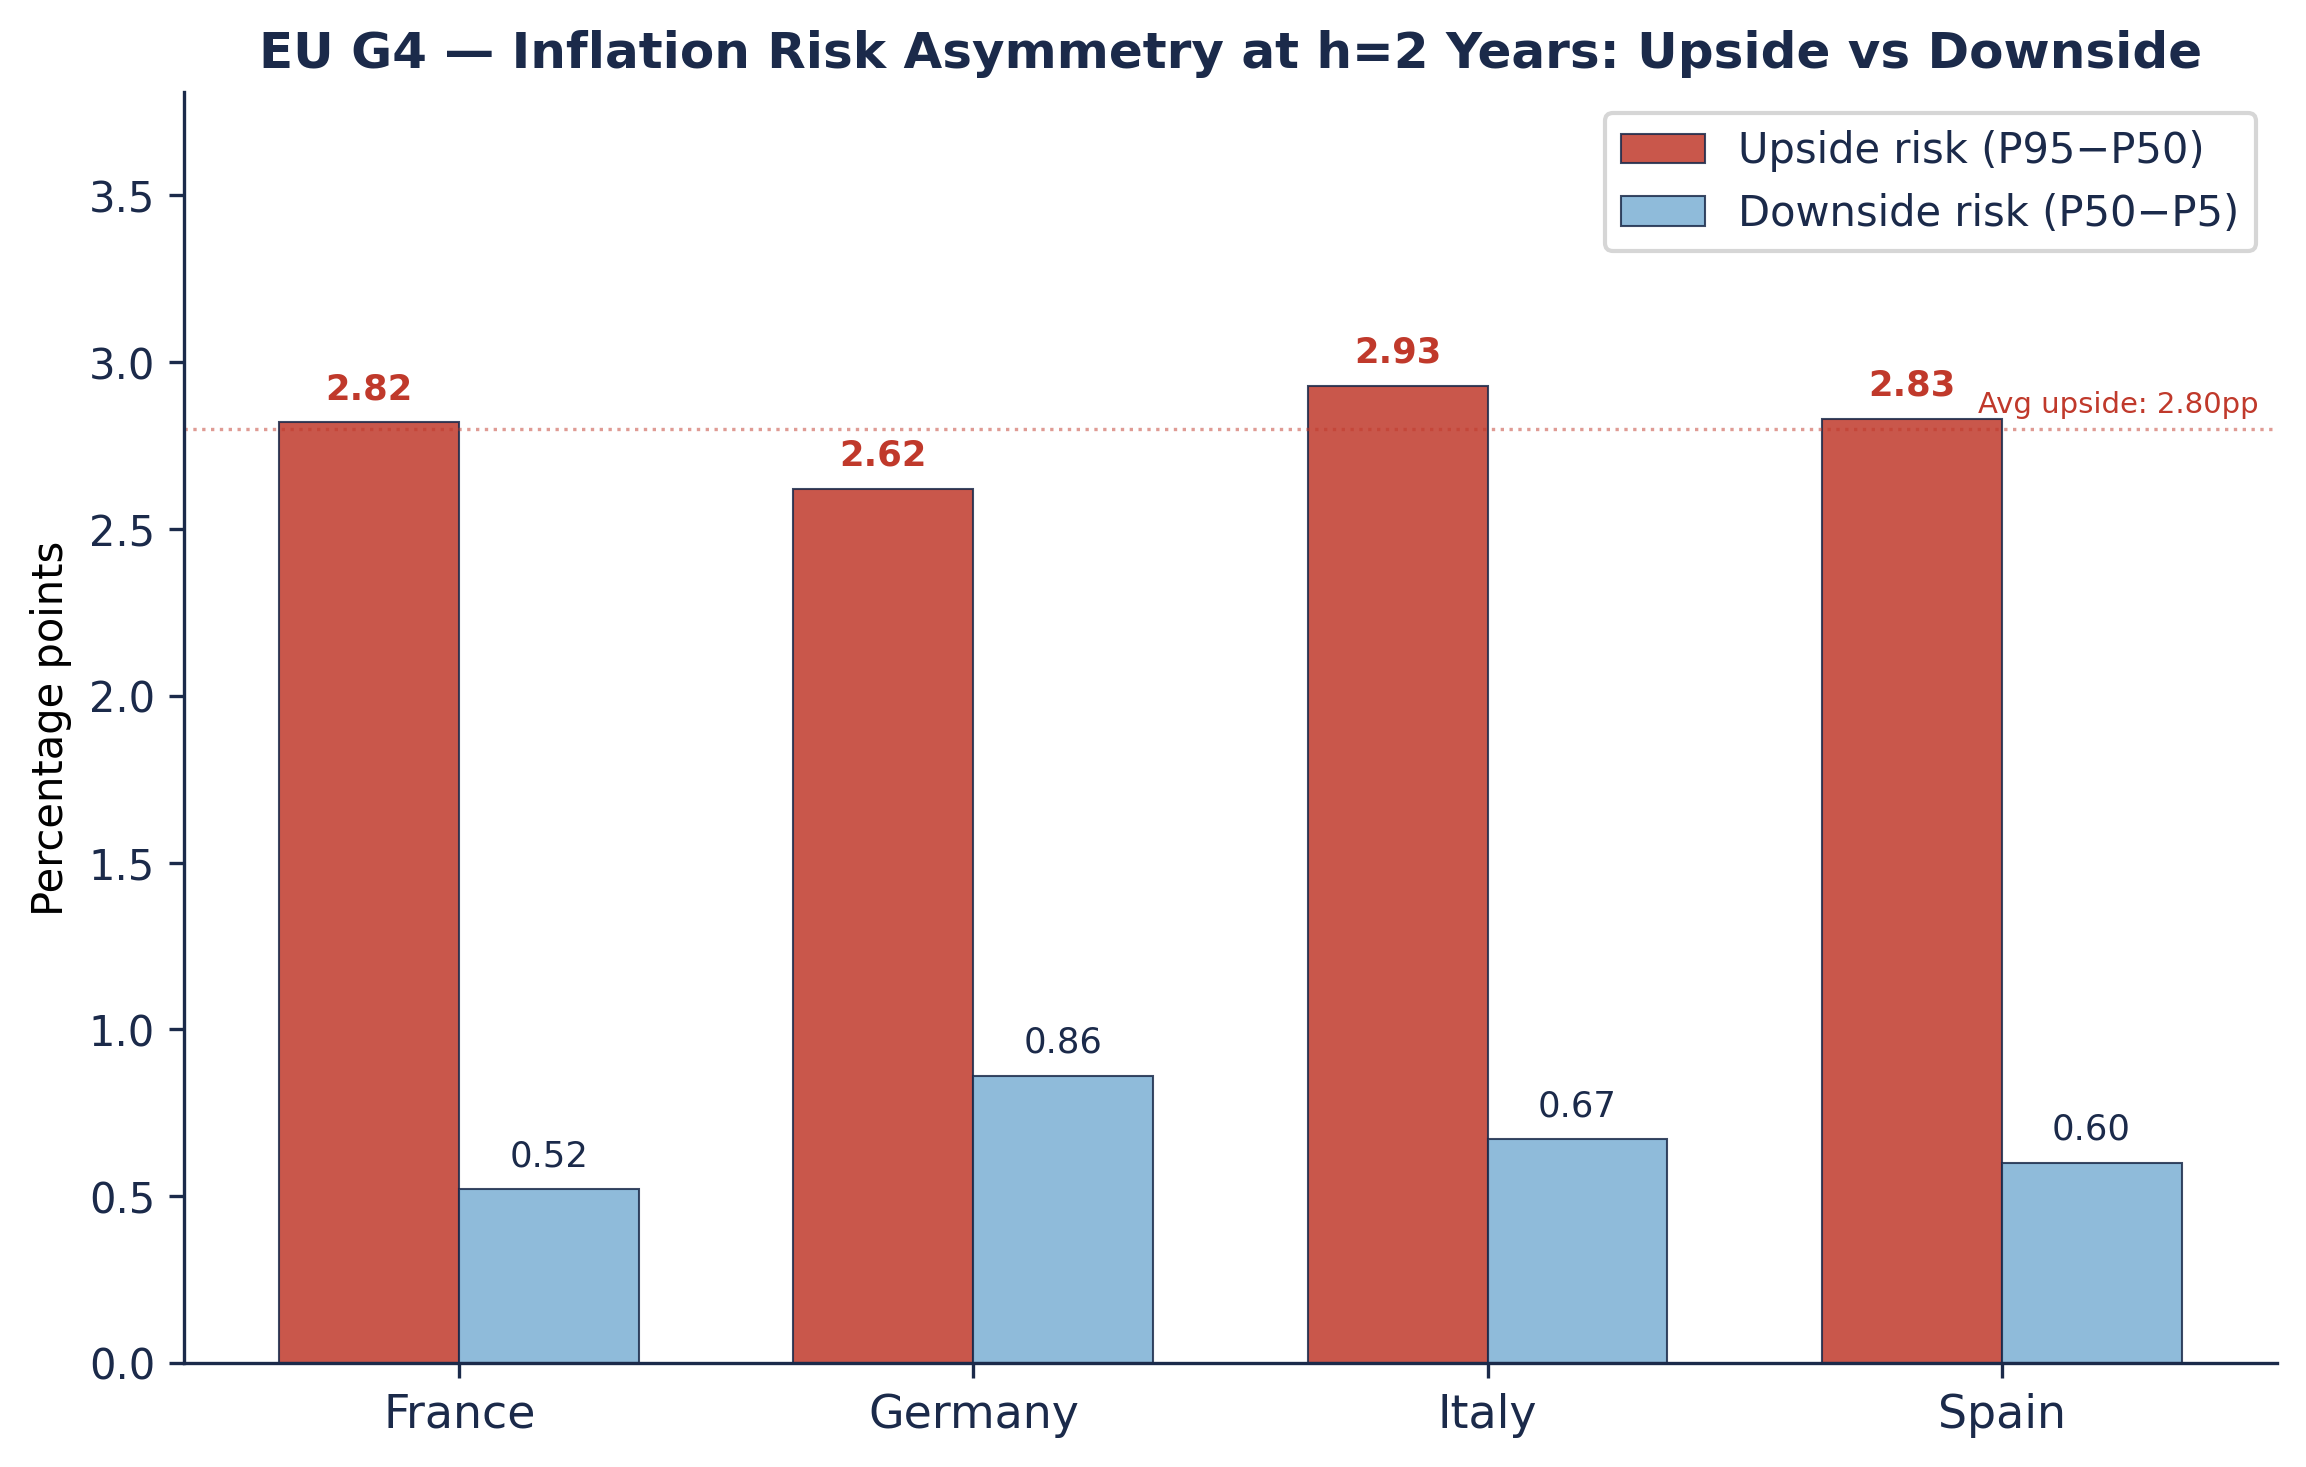

In [17]:
# ── Chart 2: Asymmetry bar ───────────────────────────────────────────────────
display(Image(str(chart_paths['asymmetry'])))

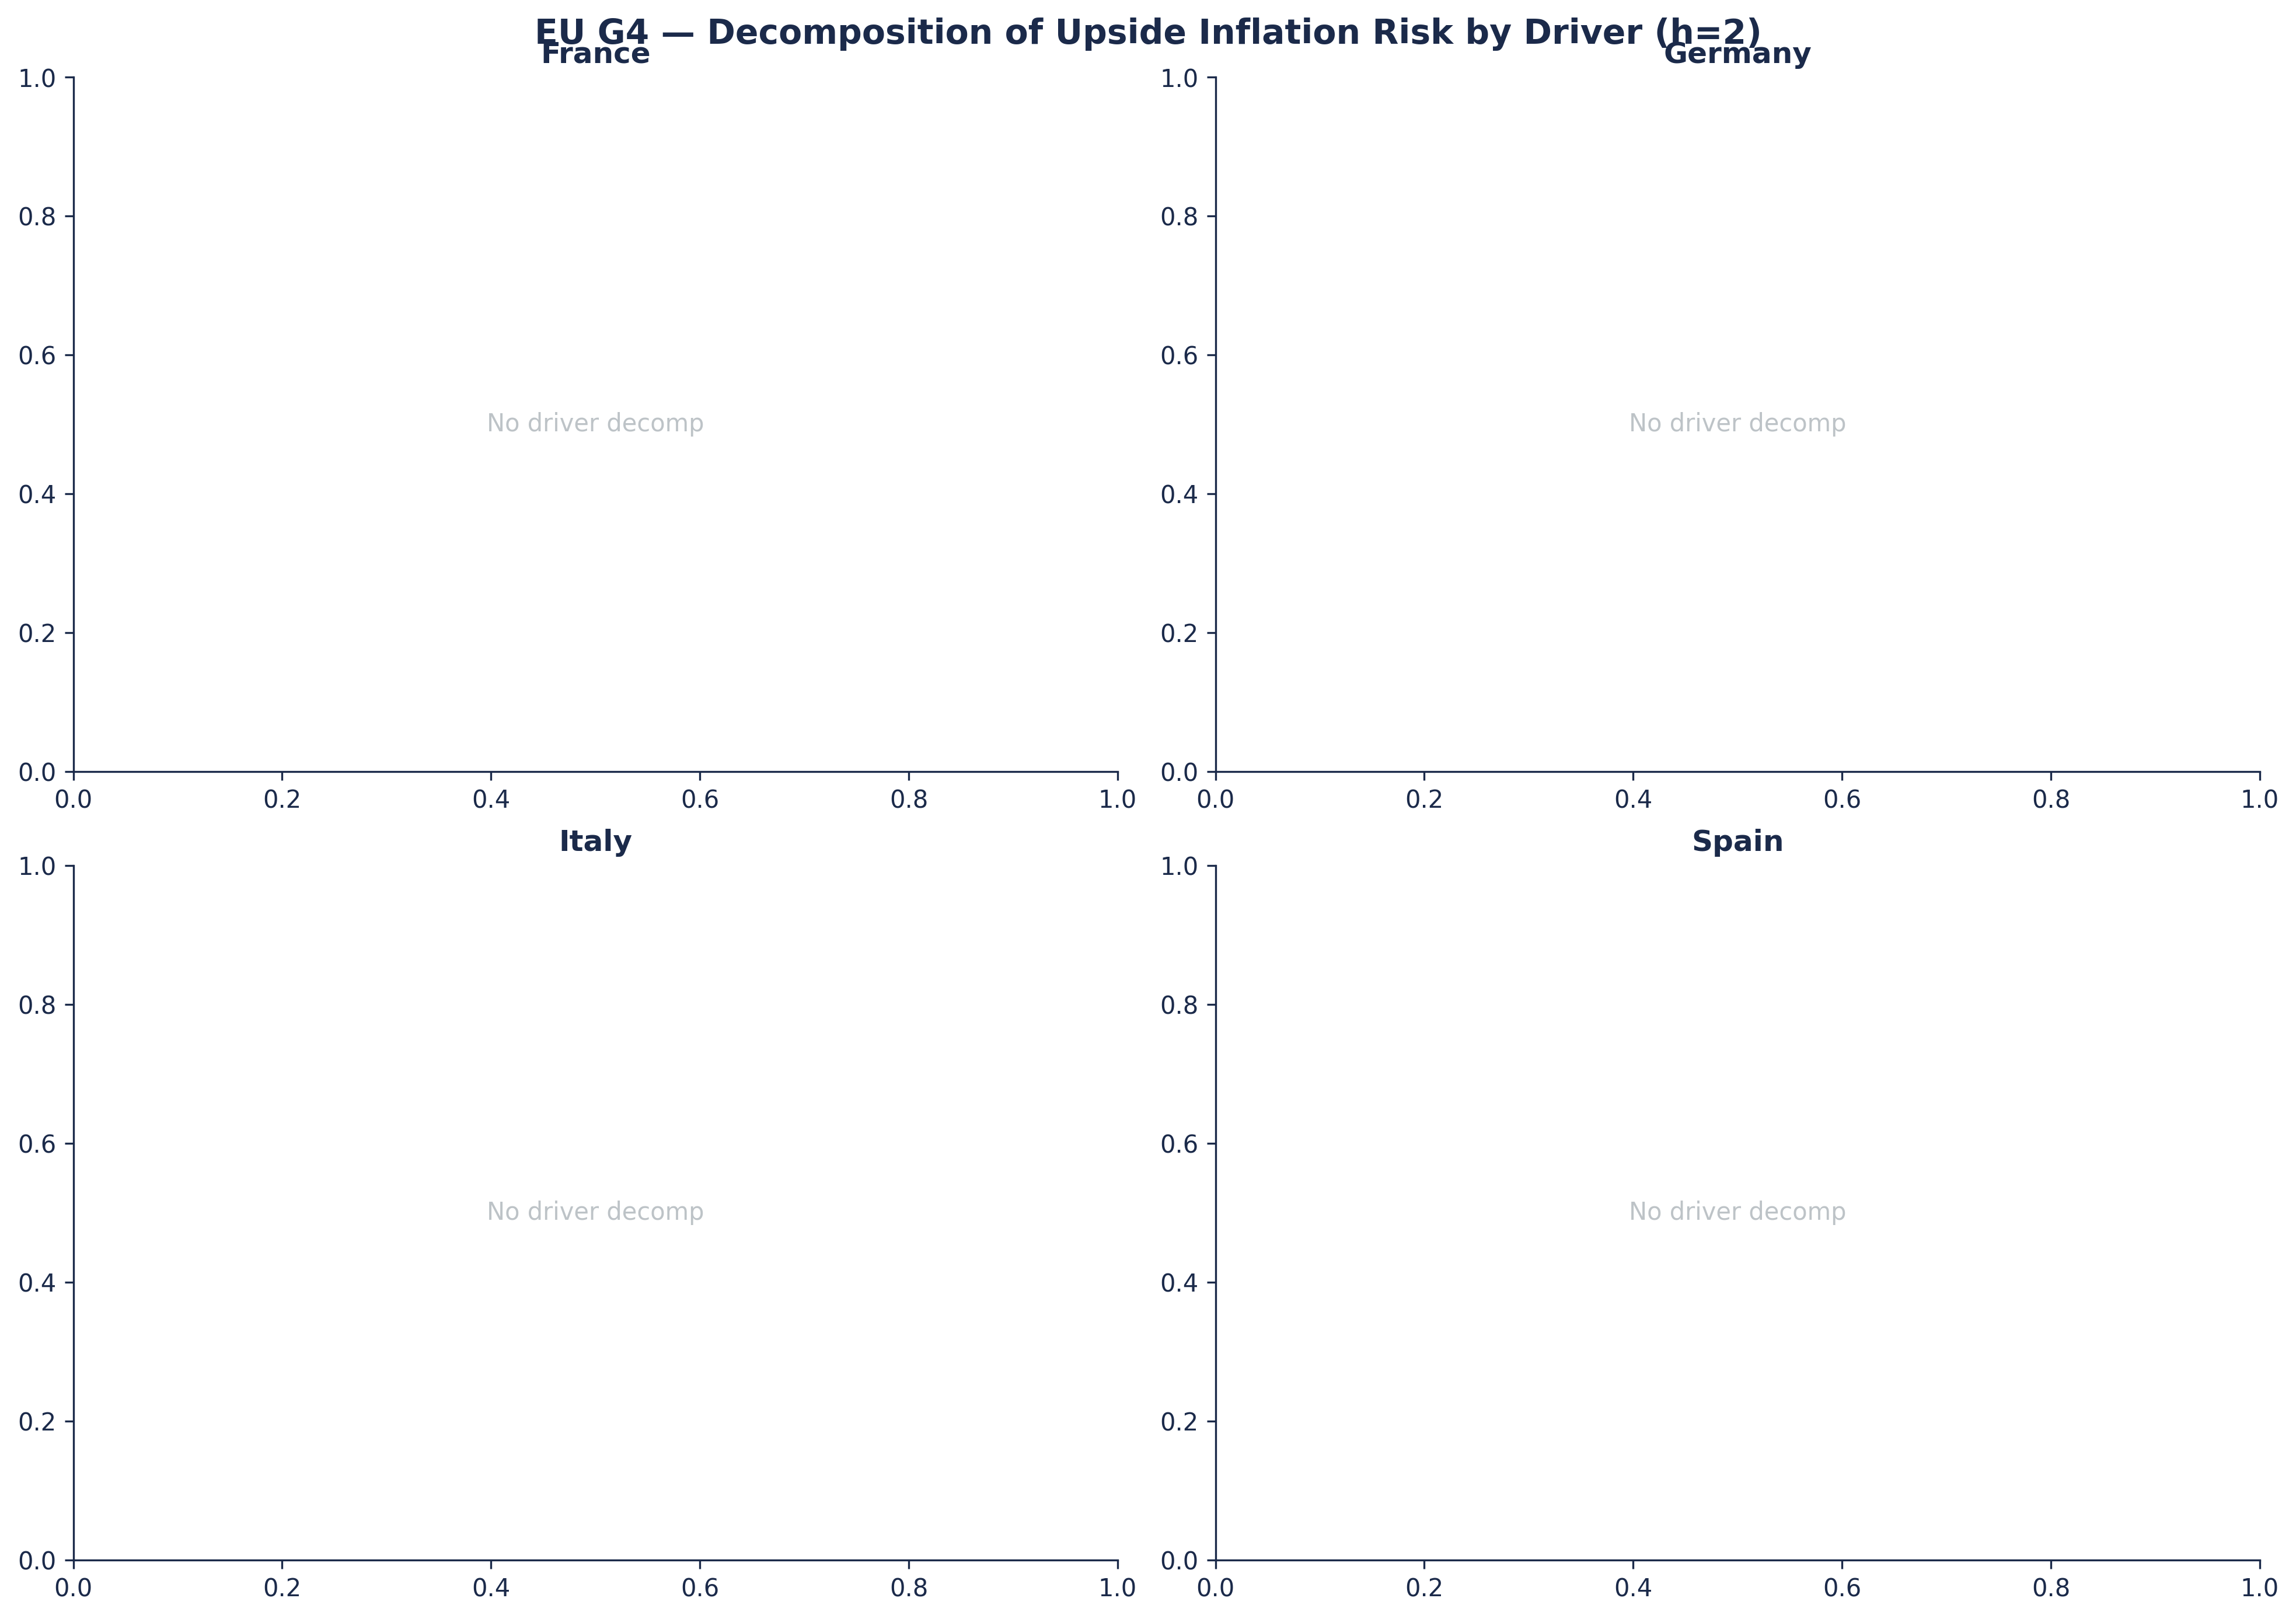

In [18]:
# ── Chart 3: Waterfall decomposition ────────────────────────────────────────
display(Image(str(chart_paths['waterfall'])))

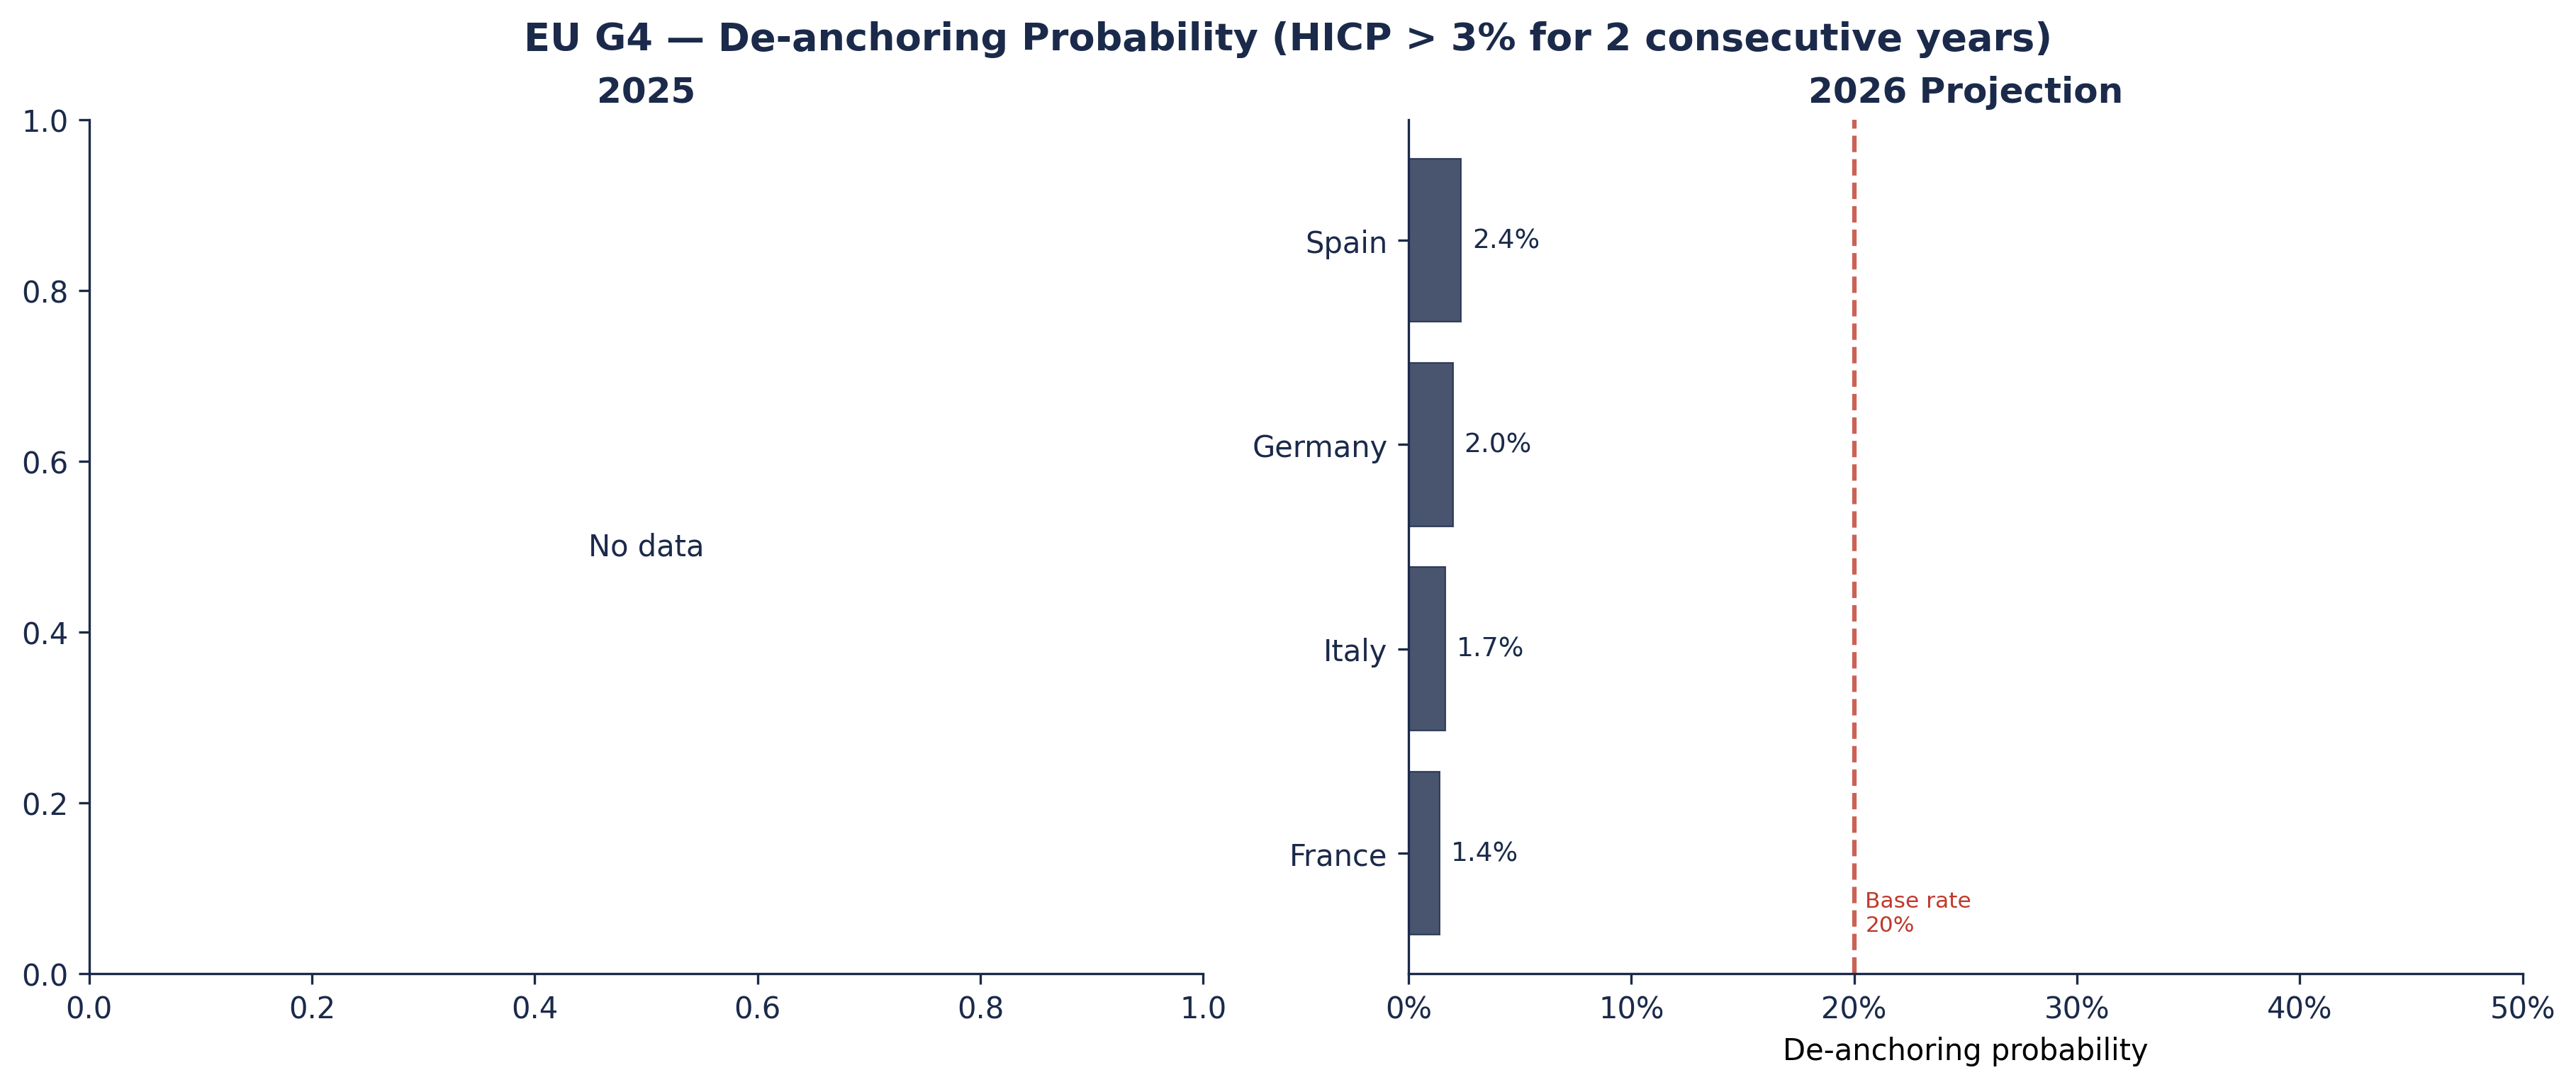

In [19]:
# ── Chart 4: De-anchoring signal ────────────────────────────────────────────
display(Image(str(chart_paths['deanchoring'])))

---
## Summary Results Table

In [22]:
# Build final summary table
summary_rows = []
for iso3 in G4:
    row   = iar[iar['iso3'] == iso3].iloc[0]
    p2026 = pooled_scores[(pooled_scores['iso3']==iso3) & (pooled_scores['year']==2026)]
    p2027 = pooled_scores[(pooled_scores['iso3']==iso3) & (pooled_scores['year']==2027)]
    summary_rows.append({
        'Country':          G4_LABELS[iso3],
        'ECB baseline 2027':f"{row['ecb_baseline']:.1f}%",
        'P50 (median)':     f"{row['Q50']:.2f}%",
        'IaR P95':          f"{row['IaR']:.2f}%",
        'Upside (pp)':      f"{row['Upside']:.2f}",
        'Downside (pp)':    f"{row['Downside']:.2f}",
        'P(deanchor) 2026': f"{p2026['pooled_prob'].values[0]:.1%}" if not p2026.empty else 'n/a',
        'P(deanchor) 2027': f"{p2027['pooled_prob'].values[0]:.1%}" if not p2027.empty else 'n/a',
    })

summary = pd.DataFrame(summary_rows).set_index('Country')
display(Markdown('### EU G4 Inflation-at-Risk Final Summary Table (h = 2 years)'))
display(summary)


### EU G4 Inflation-at-Risk Final Summary Table (h = 2 years)

,ECB baseline 2027,P50 (median),IaR P95,Upside (pp),Downside (pp),P(deanchor) 2026,P(deanchor) 2027
Country,,,,,,,
France,1.5%,1.53%,4.35%,2.82,0.52,1.4%,15.9%
Germany,2.3%,2.30%,4.92%,2.62,0.86,2.0%,16.2%
Italy,1.8%,1.77%,4.70%,2.93,0.67,1.7%,4.2%
Spain,1.9%,1.86%,4.69%,2.83,0.60,2.4%,20.9%


In [21]:
display(Markdown('''
---
**Interpretation guide:**
- **ECB baseline 2027**: Country-specific inflation forecast from EC AMECO (ZCPIH variable).
- **P50 (median)**: Model conditional median for the 2-year forward HICP rolling mean.
- **IaR P95**: 95th percentile of the conditional HICP distribution — the inflation-at-risk metric.
  By construction, IaR > ECB baseline > P05.
- **Upside (pp)**: P95 − P50 — the wideness of the *upside* tail.
- **Downside (pp)**: P50 − P05 — the wideness of the *downside* tail.
- **P(deanchor)**: Probability that HICP exceeds 3% for 2 consecutive years, from the panel logit.
  Historical base rate ≈ 20% of estimation sample.

*Model: Machado–Santos Silva (2019) three-step location-scale estimator;  
distribution: Fernández–Steel skewed-t;  
pooling: log-score weights across horizons h = {1, 2, 4};  
estimation panel: 29 EU/EEA countries, 1999–2025.*
'''))


---
**Interpretation guide:**
- **ECB baseline 2027**: Country-specific inflation forecast from EC AMECO (ZCPIH variable).
- **P50 (median)**: Model conditional median for the 2-year forward HICP rolling mean.
- **IaR P95**: 95th percentile of the conditional HICP distribution — the inflation-at-risk metric.
  By construction, IaR > ECB baseline > P05.
- **Upside (pp)**: P95 − P50 — the wideness of the *upside* tail.
- **Downside (pp)**: P50 − P05 — the wideness of the *downside* tail.
- **P(deanchor)**: Probability that HICP exceeds 3% for 2 consecutive years, from the panel logit.
  Historical base rate ≈ 20% of estimation sample.

*Model: Machado–Santos Silva (2019) three-step location-scale estimator;  
distribution: Fernández–Steel skewed-t;  
pooling: log-score weights across horizons h = {1, 2, 4};  
estimation panel: 29 EU/EEA countries, 1999–2025.*


---
## Phase 6 — Econometric Validation Suite
Six-category validation: panel structure, MSS diagnostics, skewed-t fit quality,
density pooling, OOS forecasting, and de-anchoring logit.


In [23]:
import importlib
import validation as _val_mod
importlib.reload(_val_mod)
from validation import run_validation_suite

val_results = run_validation_suite(
    panel         = panel,
    results       = results,
    skt_params    = skt_params,
    weights       = weights,
    iar           = iar,
    pooled_scores = pooled_scores,
    daresults     = daresults,
)

for cat, tbl in val_results.items():
    if cat == 'iar':
        continue
    print(f'\n── {cat.upper()} ──')
    if isinstance(tbl, dict):
        for name, df in tbl.items():
            print(f'  {name}:')
            print(df.to_string(max_rows=10))
    else:
        print(tbl.to_string(max_rows=10))



── CATEGORY1 ──
  cross_sectional_dependence:
                   N_countries  pairs_used    Tbar  mean_pair_corr  CD_stat  pvalue
variable                                                                           
hicp                   29.0000    406.0000 27.4483          0.6862 102.4396  0.0000
output_gap             29.0000    406.0000 22.8719          0.7286  99.2958  0.0000
infl_expectations      29.0000    406.0000 28.0000          0.7205 108.6443  0.0000
energy_price_chg       29.0000    406.0000 28.0000          1.0000 150.7846  0.0000
import_price_chg       29.0000    406.0000 28.0000          0.4413  66.5415  0.0000
...                        ...         ...     ...             ...      ...     ...
wui                    25.0000    300.0000 27.0000          0.3940  50.1442  0.0000
food_price_chg         29.0000    406.0000 19.6552          0.8210 103.7132  0.0000
labour_cost_chg        26.0000    325.0000 22.6062          0.3782  45.8420  0.0000
neer_chg               29.000